In [1]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from PIL import Image
from torchvision import transforms
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torchvision import transforms

Image.MAX_IMAGE_PIXELS = None
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [2]:
df = pd.read_csv("whole_dataset_splits.csv")
print(f"Total clips = {len(df)}")
vidnames = list(set(df["original_vid"]))
print(f"Total videos = {len(vidnames)}")

Total clips = 13
Total videos = 3


In [3]:
class FrameDataset(Dataset):
    def __init__(self, df, res=500, transform=None):
        self.df = df
        self.transform = transform or transforms.ToTensor()
        self.res = res

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        """
        Returns a clip tensor of shape (3, T, H, W) = (3, 10, res, res).
        The DataLoader will stack these into (B, 3, T, H, W).
        """
        vidpath = self.df["video_path"].iloc[idx]
        tensors = []
        for i in range(10):
            fname = self.df[f"frame_{i}"].iloc[idx]
            path = os.path.join(vidpath, fname)
            img = Image.open(path).convert('RGB').resize((self.res, self.res))
            tensors.append(self.transform(img))  # (3, res, res)
        clip = torch.stack(tensors, dim=1)  # (3, T, res, res)
        label = int(self.df["label"].iloc[idx])
        return clip, label


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

In [4]:
test_df = pd.read_csv("test_dataset_splits.csv")
train_df = pd.read_csv("train_dataset_splits.csv")

train_dataset = FrameDataset(train_df, res=224, transform=train_transform)
test_dataset  = FrameDataset(test_df,  res=224, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")
for frames, label in train_loader:
    print(frames.shape)
    print(label)
    break

Train samples: 9, Test samples: 4
torch.Size([9, 3, 10, 224, 224])
tensor([0, 1, 1, 0, 0, 1, 0, 1, 0])


In [5]:
# Model

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

print(f'Model:      ResNet-50 (from scratch)')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Device:     {device}')

Model:      ResNet-50 (from scratch)
Parameters: 23,512,130
Device:     cpu


In [ ]:
# Training
from sklearn.utils.class_weight import compute_class_weight

# weight classes to account for imbalance
train_labels = train_dataset.df['label'].values
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.FloatTensor(weights).to(device)

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 100

start_epoch = 0
train_losses = []
train_accs   = []

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for clips, labels in train_loader:
        clips, labels = clips.to(device), labels.to(device)
        B, C, T, H, W = clips.shape

        optimizer.zero_grad()

        frames = clips.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)  
        frame_outputs = model(frames)                                     
        outputs = frame_outputs.reshape(B, T, -1).mean(dim=1)            

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds    = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')
    if epoch % 10 == 0:
      print("saved checkpoint", epoch)
      torch.save({
          'epoch': epoch,
          'model_state_dict': model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'loss': loss,
      }, f'checkpoints_ResNet/checkpoint_epoch_{epoch}.pt')

print('\nTraining Done')

Epoch 01/1 | Loss: 0.7008 | Acc: 0.5556
saved checkpoint 0

Training Done


In [7]:
# saving training results
save_path = 'resnet50_baseline_scratch.pth'
torch.save(model.state_dict(), save_path)
print(f'Model saved to {save_path}')

Model saved to resnet50_baseline_scratch.pth


In [8]:
# Evaluation
model = models.resnet50(pretrained=False) # Change to resnet50
model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load(save_path, map_location=device))
model = model.to(device)
model.eval()
print('Model loaded.')

/Users/cvancaemelbecke/opt/anaconda3/envs/ML_TA/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/cvancaemelbecke/opt/anaconda3/envs/ML_TA/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded.


In [9]:
# Evaluation Metrics
y_true, y_pred = [], []
misclassified_fakes = []  # store filenames of fake videos misclassified as real

with torch.no_grad():
    for batch_idx, (clips, labels) in enumerate(test_loader):
        clips = clips.to(device)
        B, C, T, H, W = clips.shape

        frames = clips.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)
        frame_outputs = model(frames)
        outputs = frame_outputs.reshape(B, T, -1).mean(dim=1)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

        # Check for fake (1) predicted as real (0)
        for i in range(B):
            if labels[i].item() == 1 and preds[i] == 0:
                global_idx = batch_idx * test_loader.batch_size + i
                filepath = test_loader.dataset.df["video_path"].iloc[global_idx]
                misclassified_fakes.append(filepath)

print('=== BASELINE RESULTS (Clip-Level Averaged Logits) ===\n')
print(classification_report(
    y_true, y_pred,
    labels=[0, 1],
    target_names=['Real (0)', 'Fake (1)'],
    zero_division=0
))
print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred, labels=[0, 1]))
print(f'\nF1 (weighted): {f1_score(y_true, y_pred, average="weighted", zero_division=0):.4f}')
print(f'F1 (macro):    {f1_score(y_true, y_pred, average="macro", zero_division=0):.4f}')

# Write misclassified fakes to file
output_path = 'ResNet-50_misclassified_fakes.txt'
with open(output_path, 'w') as f:
    f.write(f"Fake videos misclassified as Real ({len(misclassified_fakes)} total):\n\n")
    for filepath in misclassified_fakes:
        f.write(filepath + '\n')

print(f'\nMisclassified fakes written to {output_path} ({len(misclassified_fakes)} videos)')

=== BASELINE RESULTS (Clip-Level Averaged Logits) ===

              precision    recall  f1-score   support

    Real (0)       0.00      0.00      0.00         0
    Fake (1)       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       0.50      0.50      0.50         4
weighted avg       1.00      1.00      1.00         4

Confusion Matrix:
[[0 0]
 [0 4]]

F1 (weighted): 1.0000
F1 (macro):    1.0000

Misclassified fakes written to ResNet-50_misclassified_fakes.txt (0 videos)


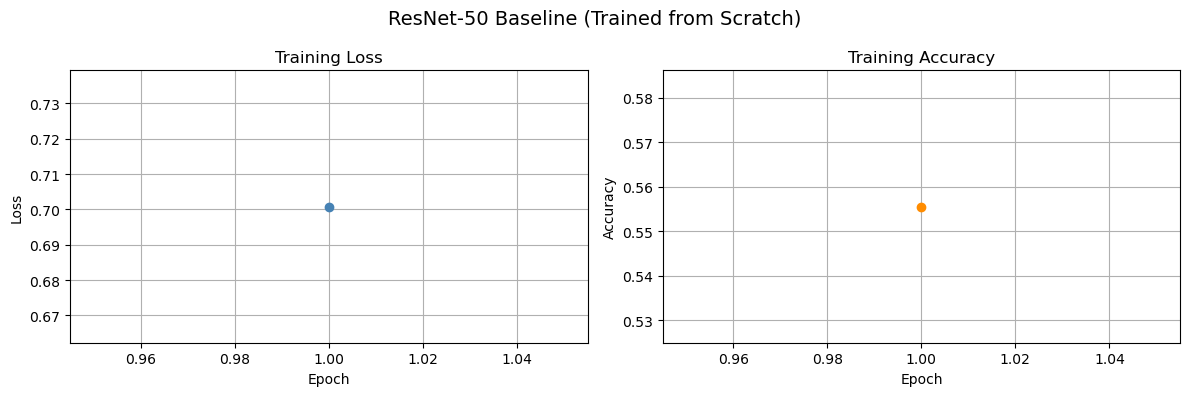

Saved


In [10]:
# Evalution plots

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, NUM_EPOCHS+1), train_losses, marker='o', color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(range(1, NUM_EPOCHS+1), train_accs, marker='o', color='darkorange')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)

plt.suptitle('ResNet-50 Baseline (Trained from Scratch)', fontsize=14)
plt.tight_layout()
plt.savefig('baseline_training_curves.png')
plt.show()
print('Saved')